# 08_get_binding_pocket_properties

Notebook for extracting binding-pocket properties with or without an explicit ligand.


## Python Path Setup


In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name == "notebooks" else cwd
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
src_root = repo_root / "src"
if src_root.exists() and str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))


## Imports


In [2]:
import importlib
import pandas as pd

import agentic_protein_design.steps.get_binding_pocket_properties as pocket_script
pocket_script = importlib.reload(pocket_script)

default_user_inputs = pocket_script.default_user_inputs
run_binding_pocket_property_extraction = pocket_script.run_binding_pocket_property_extraction


## Workflow Skeleton

1. Choose whether a ligand is present.
2. Run either `PocketAnalysis` or `LigandPocketAnalysis` from `tools/struct/`.
3. Inspect the generated binding-pocket property tables.


## User Inputs (Edit This Cell)


In [3]:
user_inputs = default_user_inputs()

# Data root key from project_config/variables.py (address_dict)
user_inputs["root_key"] = 'ECOHARVEST' # "examples"
user_inputs["data_subfolder"] = "lipases"

# Set True to use LigandPocketAnalysis, False to use PocketAnalysis
user_inputs["ligand_present"] = True

# Shared analysis settings
user_inputs["protein_molname"] = "A"
user_inputs["plot_properties"] = False
user_inputs["struct_csv_subdirectory_name"] = "structure_csv"

# Ligand-aware settings (used when ligand_present = True)
user_inputs["ligand_molname"] = "B"
user_inputs["dist_thres"] = 8
user_inputs["reactive_center_target"] = [
    {"enz":'RML', "protein":[144,203,257], "ligand":'O2'},
    {"enz":'TLL', "protein":[146,201,258], "ligand":'O2'}
]
user_inputs["keep_pos_with_aa_variation_only"] = False
user_inputs["analyse_binding_pocket_without_ligand"] = True
user_inputs["seq_align_fname"] = 'RML_TLL_ali.fasta' # "UPO_peroxygenation_ali.fasta"
user_inputs["binding_pocket_residues_fname"] = "residues_near_ligand.csv"
user_inputs["struct_dict"] = {
    # lipases
    "RML": 'RML_SucroseOleate',
    "TLL": "TLL_SucroseOleate",
    # "CALB": "CALB_SucroseOleate",
    # "CALA": "CALA_SucroseOleate",
    # # UPOs
    # "ET096": "ET096_S82",
    # "CviUPO": "CviUPO_S82",
    # "DcaUPO": "DcaUPO_S82",
    # "TE314": "TE314_S82",
    # "OA167": "OA167_S82",
}

# Ligand-free settings (used when ligand_present = False)
# pocket_residues_source = "csv": load {root}/pdb/{data_subfolder}/binding_pocket_residues_fname
# pocket_residues_source = "inline": use pocket_residues_dict below
user_inputs["pocket_residues_source"] = "csv"
user_inputs["pocket_residues_dict"] = {
    # "ET096": [69, 73, 158],
    # "CviUPO": [69, 73, 158],
}

user_inputs


{'root_key': 'ECOHARVEST',
 'data_subfolder': 'lipases',
 'ligand_present': True,
 'protein_molname': 'A',
 'ligand_molname': 'B',
 'dist_thres': 8,
 'reactive_center_target': [{'enz': 'RML',
   'protein': [144, 203, 257],
   'ligand': 'O2'},
  {'enz': 'TLL', 'protein': [146, 201, 258], 'ligand': 'O2'}],
 'keep_pos_with_aa_variation_only': False,
 'plot_properties': False,
 'analyse_binding_pocket_without_ligand': True,
 'seq_align_fname': 'RML_TLL_ali.fasta',
 'binding_pocket_residues_fname': 'residues_near_ligand.csv',
 'struct_csv_subdirectory_name': 'structure_csv',
 'pocket_residues_source': 'csv',
 'pocket_residues_dict': {},
 'struct_dict': {'RML': 'RML_SucroseOleate', 'TLL': 'TLL_SucroseOleate'}}

## Run Binding Pocket Property Extraction


struct_fpaths: 2
[PosixPath('/Users/charmainechia/Documents/projects/ECOHARVEST/pdb/lipases/RML_SucroseOleate.pdb'), PosixPath('/Users/charmainechia/Documents/projects/ECOHARVEST/pdb/lipases/TLL_SucroseOleate.pdb')]
Ref Object: RML_SucroseOleate.pdb (269 residues) 

TLL_SucroseOleate.pdb (269 residues)
TM-align score: None
RMSD (superposed residues): 0
RMSD (aligned residues): 1.44
# of aligned residues: 231/269 (85.9%)
[IDENTICAL] all: 76 (32.9%); hydrophobic: 34 (14.7%); non-hydrophobic: 42 (18.2%)
[SIMILAR] all: 132 (57.1%); hydrophobic: 68 (29.4%); non-hydrophobic: 64 (27.7%)

struct_fpaths: 2 [PosixPath('/Users/charmainechia/Documents/projects/ECOHARVEST/pdb/lipases/RML_SucroseOleate.pdb'), PosixPath('/Users/charmainechia/Documents/projects/ECOHARVEST/pdb/lipases/TLL_SucroseOleate.pdb')]
Saved SCE output: /Users/charmainechia/Documents/projects/ECOHARVEST/sce/lipases/RML_TLL_ali.sce
num_obj: 2
Saved PDB output: /Users/charmainechia/Documents/projects/ECOHARVEST/pdb/lipases/RML_Suc

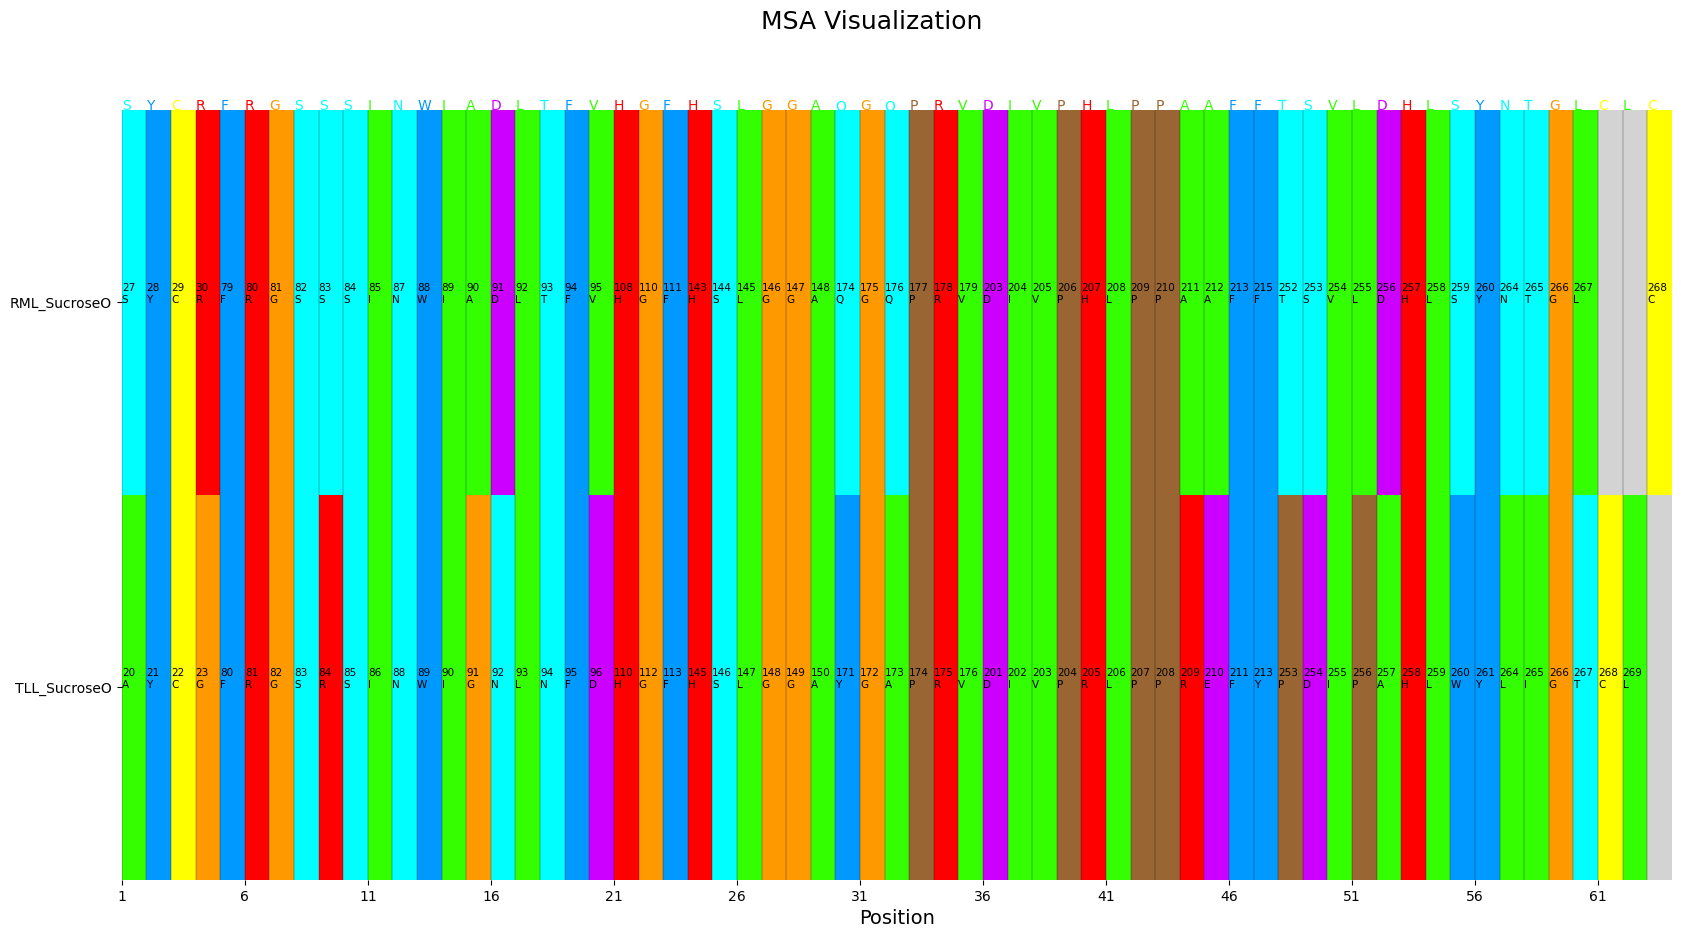

Parsed 2125 atoms >> Saved CSV to: /Users/charmainechia/Documents/projects/ECOHARVEST/pdb/lipases/structure_csv/RML_SucroseOleate.csv
Parsed 2105 atoms >> Saved CSV to: /Users/charmainechia/Documents/projects/ECOHARVEST/pdb/lipases/structure_csv/TLL_SucroseOleate.csv
[RML_SucroseOleate] Binding Pocket residues (57): [28, 29, 30, 79, 80, 81, 82, 83, 84, 85, 87, 88, 89, 90, 91, 92, 93, 94, 95, 108, 110, 111, 143, 144, 145, 146, 147, 148, 174, 175, 176, 177, 178, 179, 203, 204, 205, 206, 207, 208, 209, 210, 213, 215, 253, 254, 255, 256, 257, 258, 259, 260, 264, 265, 266, 267, 268]
reactive_center_target: {'enz': 'RML', 'protein': [144, 203, 257], 'ligand': 'O2'}
target_residue: [144, 203, 257]
[RECEPTOR] Reactive center coords: [ 3.62566667  8.101375   -5.19208333]
target_ligand_element: ['O2']
[LIGAND] Reactive center coords: [ 8.277  8.173 -0.819]
[TLL_SucroseOleate] Binding Pocket residues (60): [20, 21, 22, 80, 81, 82, 83, 84, 85, 86, 88, 89, 90, 91, 92, 93, 94, 95, 96, 110, 112, 113,

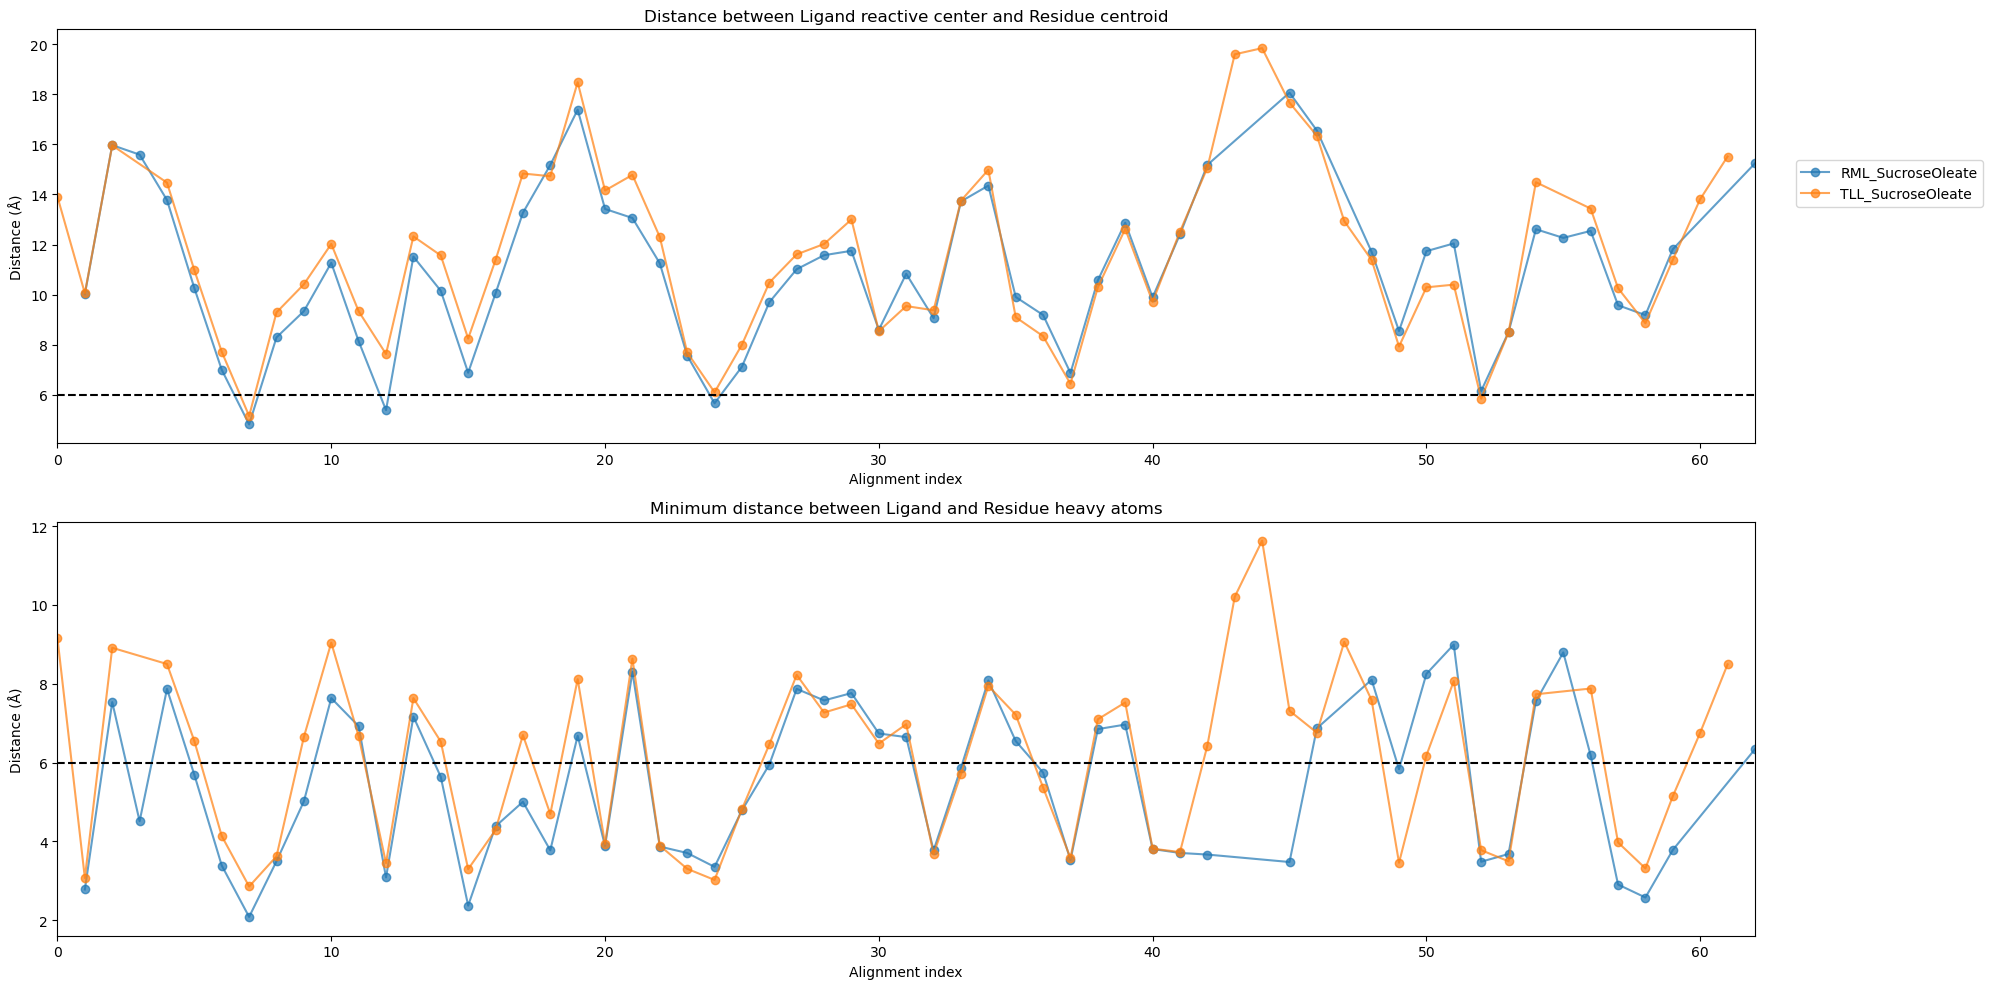

  1 29 28Y 21Y 2.78 3.072
  2 97 80R 81R 5.688 6.545
  3 98 81G 82G 3.388 4.136
  4 99 82S 83S 2.084 2.856
* 5 100 83S 84R 3.497 3.622
  6 101 84S 85S 5.017 6.651
  7 104 87N 88N 6.924 6.669
  8 105 88W 89W 3.085 3.449
  9 106 89I 90I 7.167 7.634
* 10 107 90A 91G 5.637 6.532
* 11 108 91D 92N 2.37 3.296
  12 109 92L 93L 4.383 4.288
* 13 110 93T 94N 5.004 6.698
  14 111 94F 95F 3.774 4.696
  15 126 108H 110H 3.884 3.938
  16 129 111F 113F 3.869 3.891
  17 161 143H 145H 3.706 3.305
  18 162 144S 146S 3.354 3.022
  19 163 145L 147L 4.787 4.817
  20 164 146G 148G 5.949 6.46
  21 166 148A 150A 7.577 7.269
* 22 197 174Q 171Y 7.763 7.478
  23 198 175G 172G 6.738 6.482
* 24 199 176Q 173A 6.646 6.972
  25 200 177P 174P 3.77 3.677
  26 201 178R 175R 5.864 5.707
  27 227 203D 201D 6.546 7.215
  28 228 204I 202I 5.746 5.367
  29 229 205V 203V 3.526 3.579
  30 230 206P 204P 6.849 7.099
* 31 231 207H 205R 6.964 7.525
  32 232 208L 206L 3.806 3.816
  33 233 209P 207P 3.707 3.729
  34 234 210P 208P 3.6

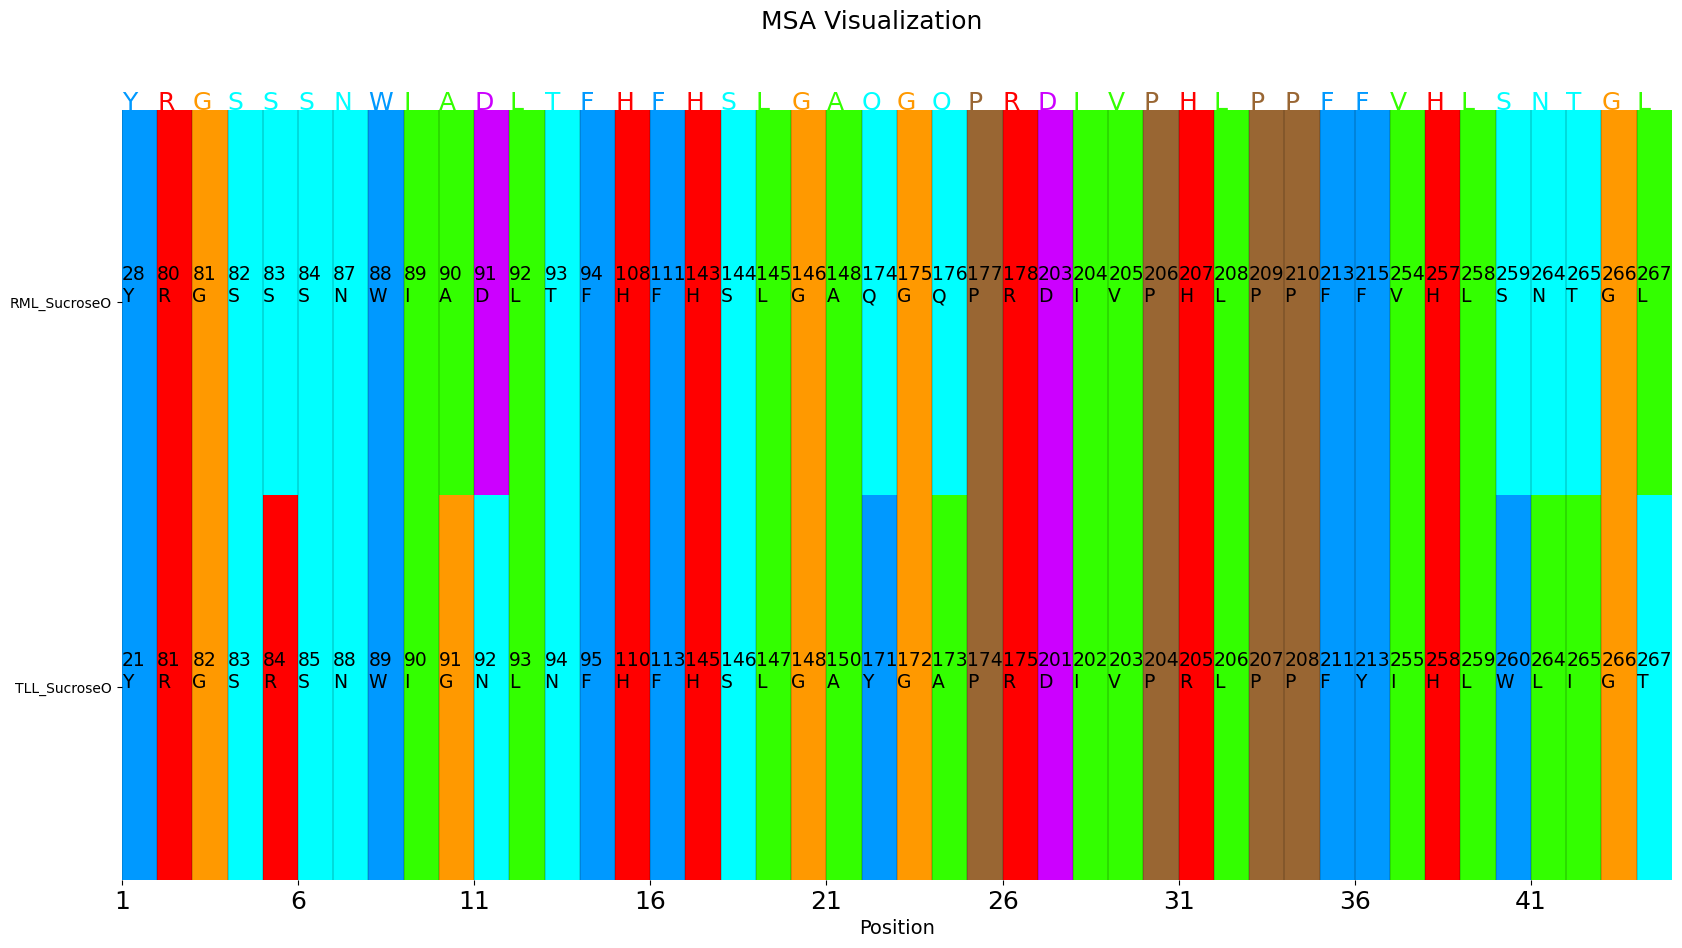

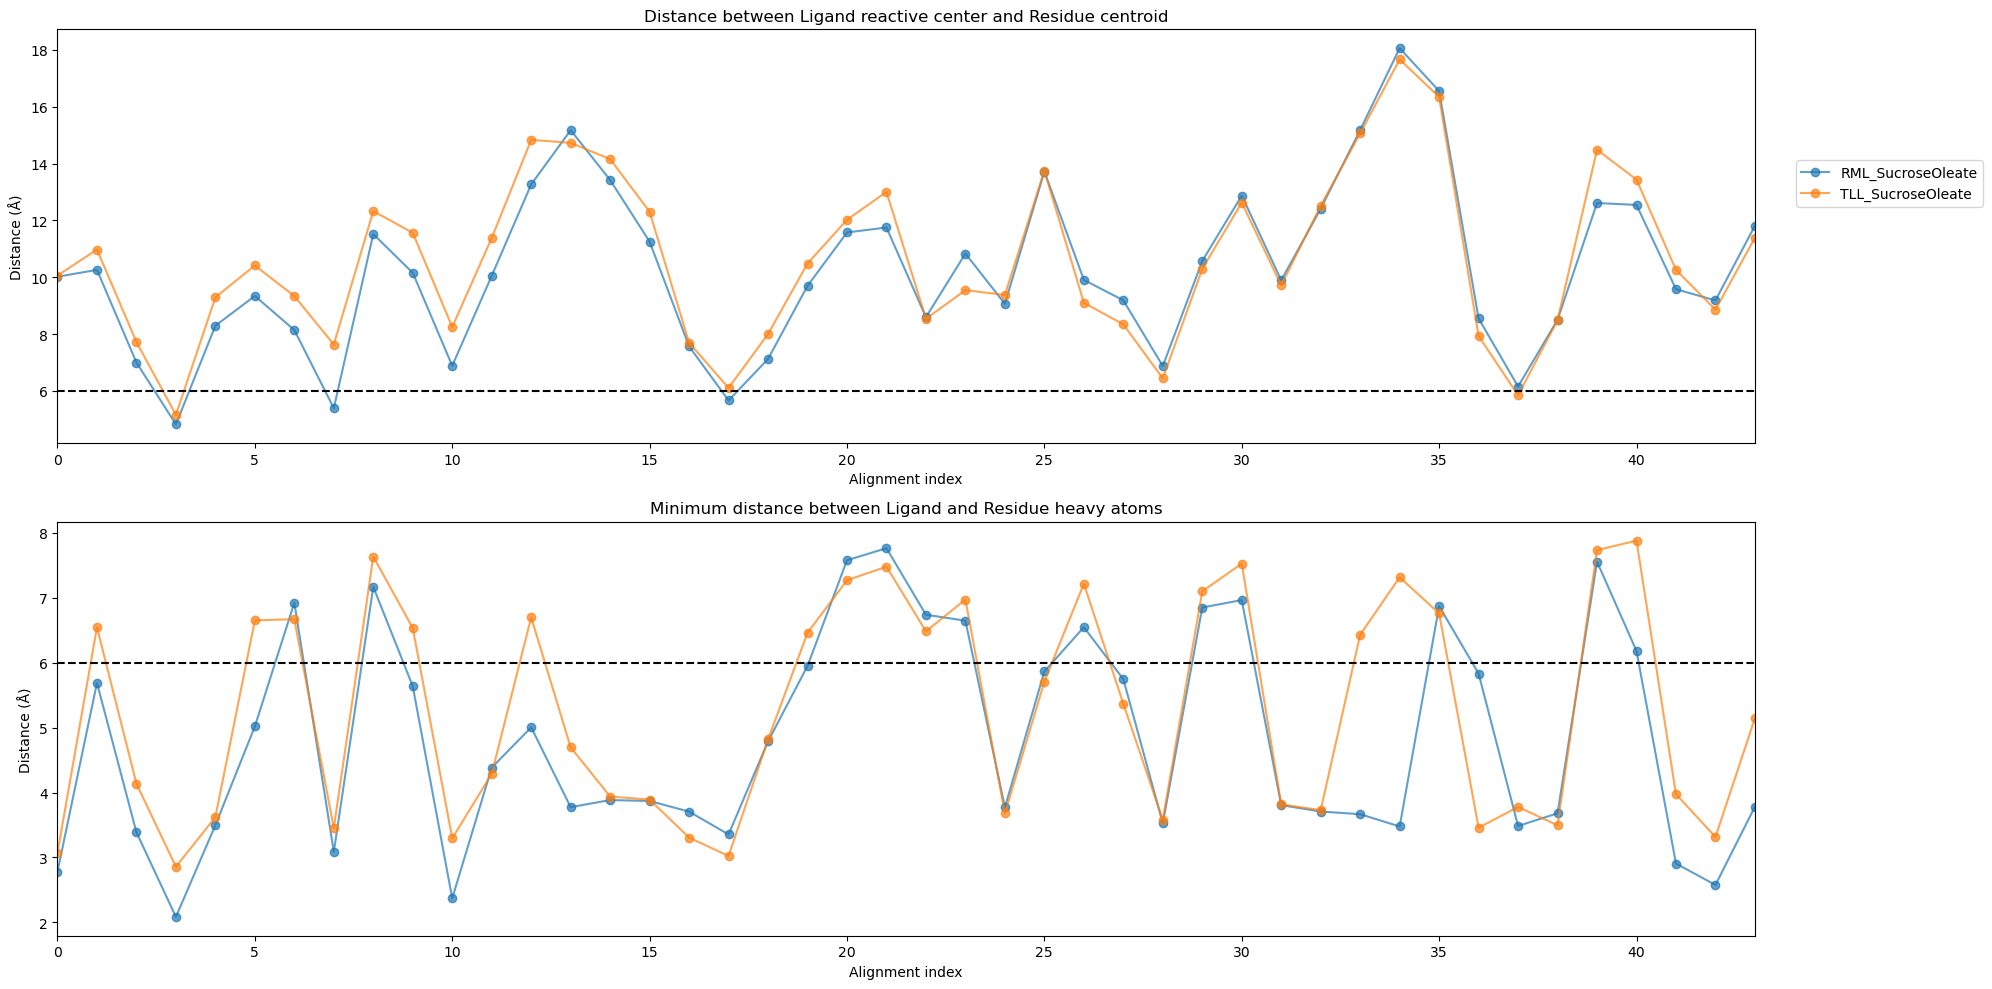

Saved all aligned proteins to YASARA scene: /Users/charmainechia/Documents/projects/ECOHARVEST/sce/lipases/RML_TLL_ali.sce
Saved RML to YASARA scene.
Saved TLL to YASARA scene.
Parsed 2125 atoms
Saved CSV to: /Users/charmainechia/Documents/projects/ECOHARVEST/pdb/lipases/structure_csv/RML_SucroseOleate.csv
[RML_SucroseOleate] Binding pocket residues  (57): [28, 29, 30, 79, 80, 81, 82, 83, 84, 85, 87, 88, 89, 90, 91, 92, 93, 94, 95, 108, 110, 111, 143, 144, 145, 146, 147, 148, 174, 175, 176, 177, 178, 179, 203, 204, 205, 206, 207, 208, 209, 210, 213, 215, 253, 254, 255, 256, 257, 258, 259, 260, 264, 265, 266, 267, 268]
Centroid: [ 7.03545089  4.94854241 -1.88751786]
--- All Residue Atoms ---
Mean distance to binding pocket centroid: 10.6929
Mean MIN distance to binding pocket centroid: 8.8556
--- Backbone Only ---
Mean distance to binding pocket centroid: 10.457
Mean MIN distance to binding pocket centroid: None

Parsed 2105 atoms
Saved CSV to: /Users/charmainechia/Documents/projects/EC

In [4]:
result = run_binding_pocket_property_extraction(user_inputs)
print("status:", result.get("status", ""))
print("ligand_present:", result.get("ligand_present", ""))
print("combined_analysis_path:", result.get("combined_analysis_path", ""))
